In [4]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
df = pd.read_csv("advertising.csv")

In [6]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
df.columns = df.columns.str.strip().str.lower()

In [10]:
df.isnull().sum()

tv           0
radio        0
newspaper    0
sales        0
dtype: int64

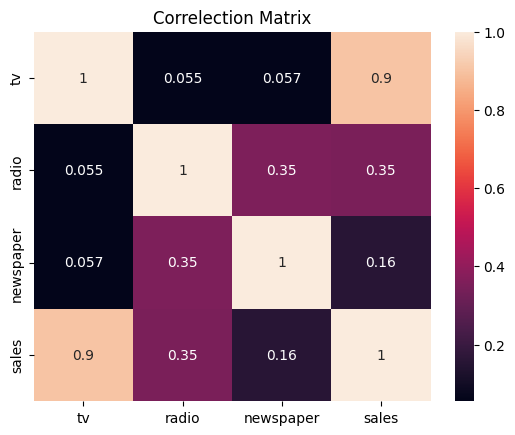

In [11]:
plt.figure()
sns.heatmap(df.corr(),annot=True)
plt.title("Correlection Matrix")
plt.show()

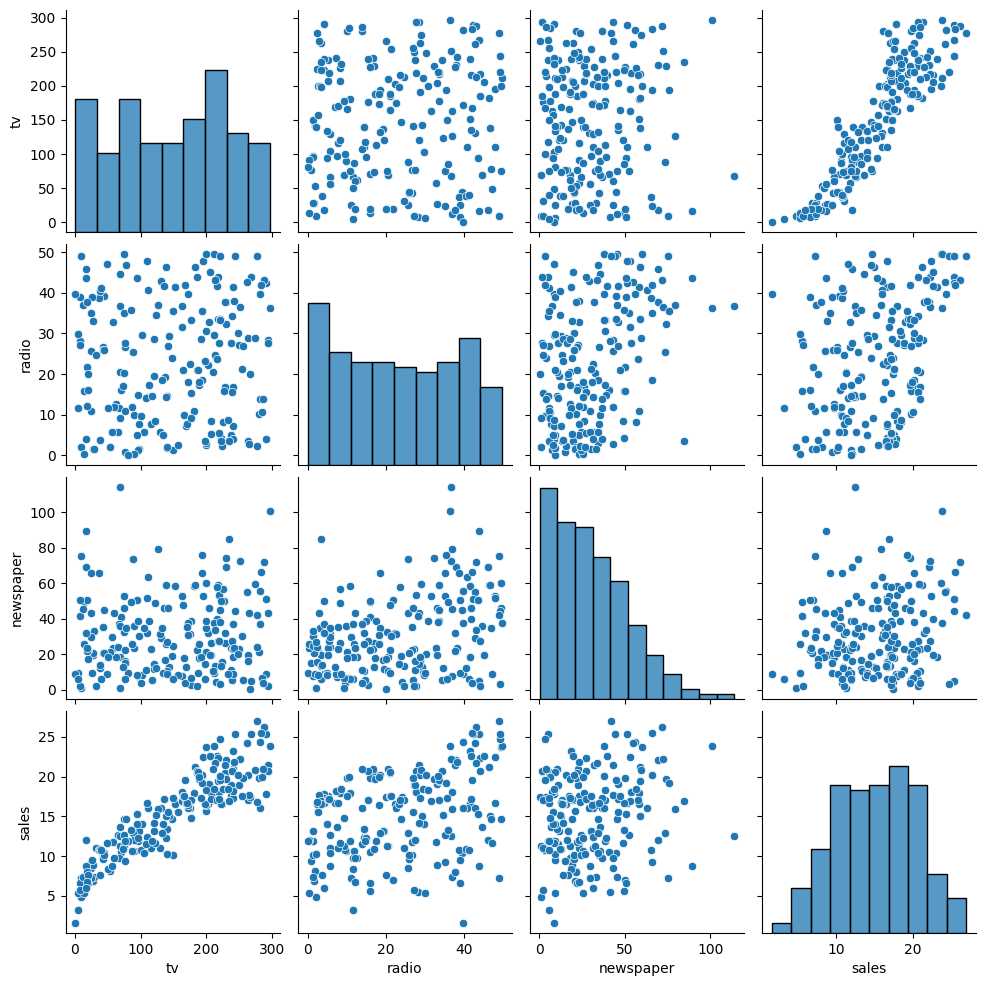

In [12]:
sns.pairplot(df)
plt.show()

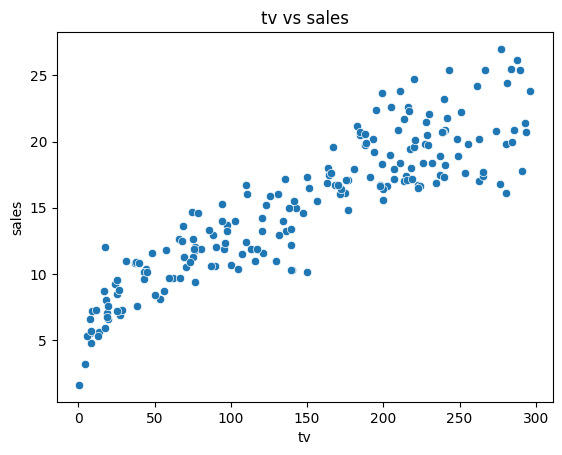

In [13]:
plt.figure()
sns.scatterplot(x=df['tv'],y=df['sales'])
plt.title("tv vs sales")
plt.show()

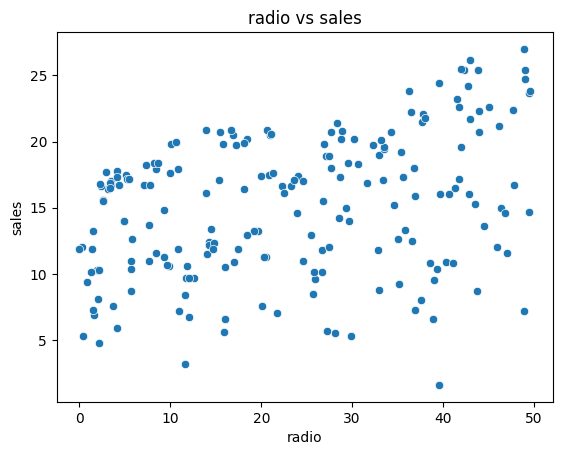

In [14]:
plt.figure()
sns.scatterplot(x=df['radio'],y=df['sales'])
plt.title("radio vs sales")
plt.show()

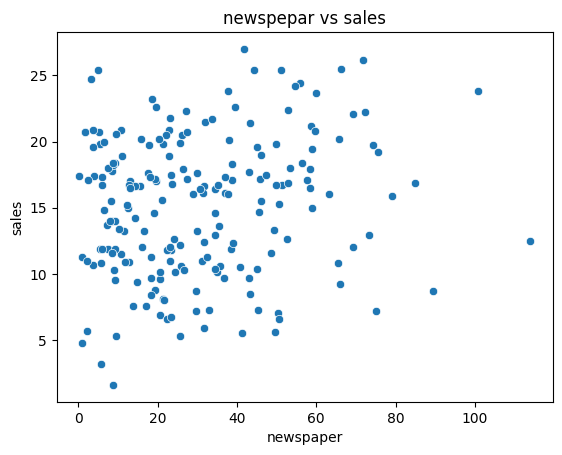

In [15]:
plt.figure()
sns.scatterplot(x=df['newspaper'],y=df['sales'])
plt.title("newspepar vs sales")
plt.show()

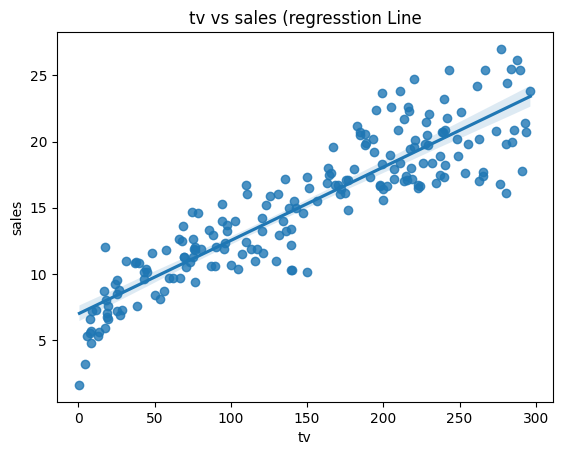

In [16]:
plt.figure()
sns.regplot(x=df['tv'],y=df['sales'])
plt.title("tv vs sales (regresstion Line")
plt.show()

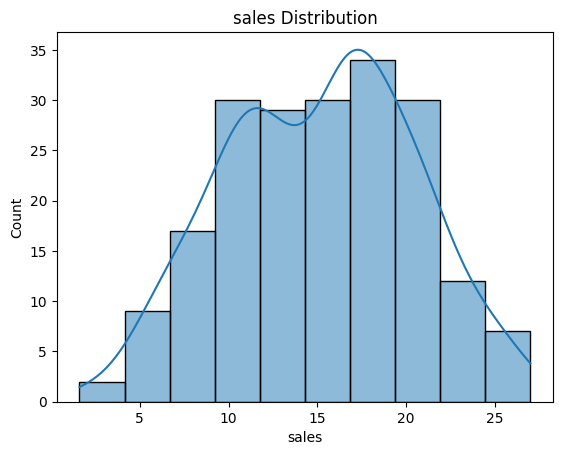

In [17]:
plt.figure()
sns.histplot(df['sales'],kde=True)
plt.title("sales Distribution")
plt.show()

In [18]:
X = df[['tv', 'radio', 'newspaper']]
y = df['sales']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
print("\nModel Coefficients:")
print(f"TV: {model.coef_[0]}")
print(f"Radio: {model.coef_[1]}")
print(f"Newspaper: {model.coef_[2]}")
print(f"Intercept: {model.intercept_}")


Model Coefficients:
TV: 0.05450927083721978
Radio: 0.10094536239295579
Newspaper: 0.0043366468220340446
Intercept: 4.714126402214127


In [22]:
y_pred = model.predict(X_test)

In [23]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("R2 Score:", r2)


Model Performance:
MSE: 2.9077569102710896
R2 Score: 0.9059011844150826


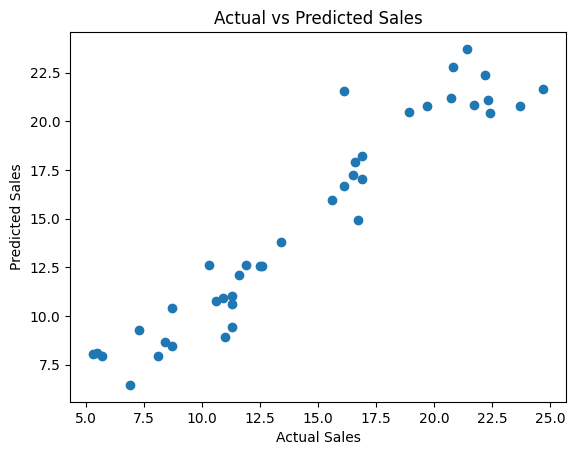

In [24]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

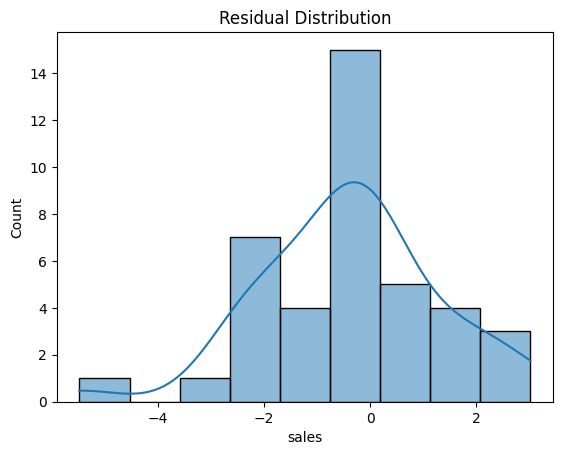

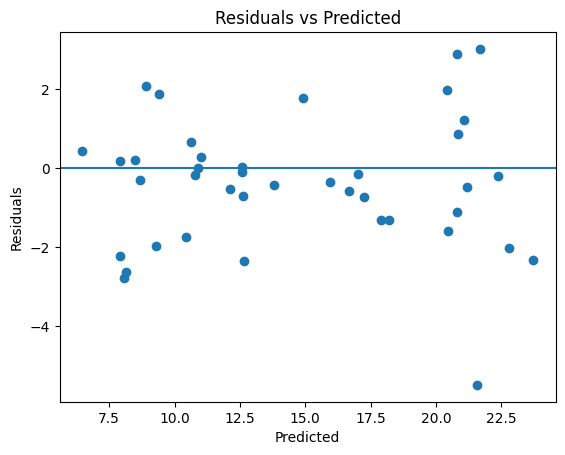

In [25]:
residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [26]:
import pickle

with open("advertising_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("\nModel saved successfully!")


Model saved successfully!
